In [52]:
import os
import numpy as np
import pandas as pd

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print(filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/nnm24is112kruthin
/kaggle/input/datasets/nnm24is112kruthin/spinal
/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS
/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS/Pathological Spine MRI Datasets
/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS/Pathological Spine MRI Datasets/SP22
S82231_MobiView_SURVEY_SAG_20260228094046_202.nii
S82231_eT1W_TSE_CLEAR_20260228094046_702_i00005.nii
S82231_eT2W_TSE_DRIVE_HR_20260228094046_802_i00013.nii
S82231_eT1W_TSE_CLEAR_20260228094046_702_i00013.nii
S82231_eT2W_TSE_DRIVE_HR_20260228094046_802_i00001.nii
S82231_eT2W_TSE_DRIVE_HR_20260228094046_802_i00005.nii
S82231_eT2W_TSE_DRIVE_HR_20260228094046_602_i00001.nii
S82231_eT1W_TSE_CLEAR_20260228094046_902_i00014.nii
S82231_eT2W_TSE_DRIVE_HR_20260228094046_602_i00010.nii
S82231_eT2W_TSE_DRIVE_HR_20260228094046_602_i00005.nii
S82231_eT1W_TSE_CLEAR_20260228094046_702_i00001.nii
S82231_eT2W_TSE_DRIVE_HR_202

In [53]:
!pip install nibabel
!pip install SimpleITK
!pip install scikit-image
!pip install opencv-python

In [54]:
import os
import cv2
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from skimage import exposure

In [55]:
nii_files = []

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            nii_files.append(os.path.join(dirname, filename))

print("Total MRI files:", len(nii_files))
print("First MRI file:", nii_files[0])

Total MRI files: 357
First MRI file: /kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS/Pathological Spine MRI Datasets/SP22/S82231_MobiView_SURVEY_SAG_20260228094046_202.nii


In [56]:
path = nii_files[0]
print(path)

/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS/Pathological Spine MRI Datasets/SP22/S82231_MobiView_SURVEY_SAG_20260228094046_202.nii


In [57]:
nii = nib.load(path)
image = nii.get_fdata()

print("Image Shape:", image.shape)
print("Image Type:", image.dtype)

Image Shape: (528, 1017, 5)
Image Type: float64


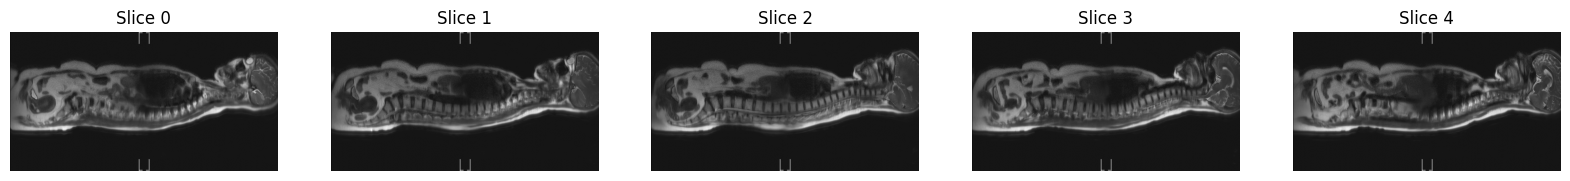

In [58]:
fig, axes = plt.subplots(1, image.shape[2], figsize=(20,5))

for i in range(image.shape[2]):
    axes[i].imshow(image[:, :, i], cmap='gray')
    axes[i].set_title(f"Slice {i}")
    axes[i].axis("off")

plt.show()

In [59]:
print("Shape:", image.shape)
print("Minimum:", np.min(image))
print("Maximum:", np.max(image))
print("Mean:", np.mean(image))
print("Standard Deviation:", np.std(image))

Shape: (528, 1017, 5)
Minimum: 0.0
Maximum: 2744.781732559204
Mean: 491.83989455443987
Standard Deviation: 395.1392467585791


In [60]:
print("NaN values :", np.isnan(image).sum())
print("Infinite values :", np.isinf(image).sum())

NaN values : 0
Infinite values : 0


In [61]:
image_norm = (image - np.min(image)) / (np.max(image) - np.min(image))

print("Normalized Min :", image_norm.min())
print("Normalized Max :", image_norm.max())

Normalized Min : 0.0
Normalized Max : 1.0


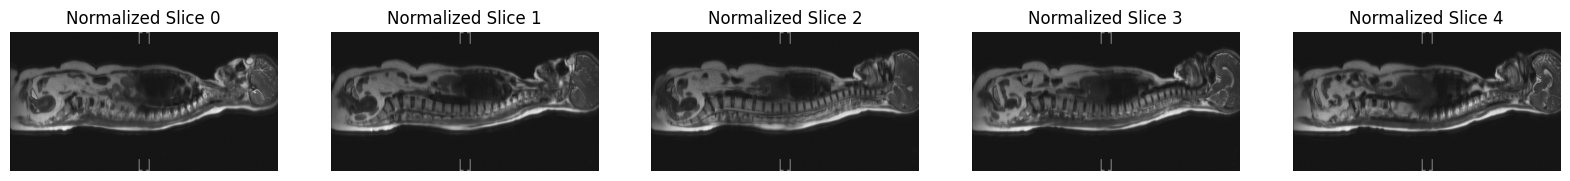

In [62]:
fig, axes = plt.subplots(1, image_norm.shape[2], figsize=(20,5))

for i in range(image_norm.shape[2]):
    axes[i].imshow(image_norm[:, :, i], cmap='gray')
    axes[i].set_title(f"Normalized Slice {i}")
    axes[i].axis("off")

plt.show()


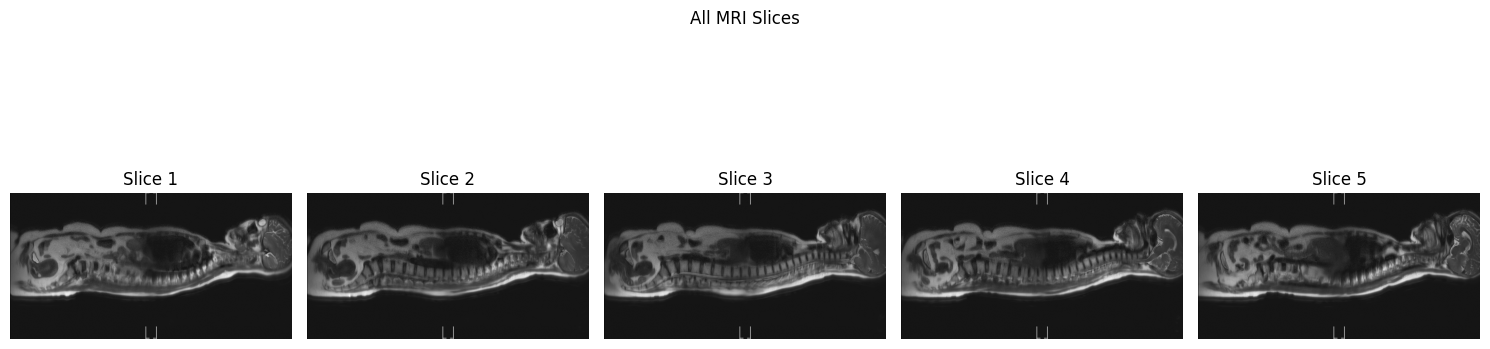

In [63]:
# Display all slices of the loaded MRI volume

num_slices = image.shape[2]

plt.figure(figsize=(15, 5))

for i in range(num_slices):
    plt.subplot(1, num_slices, i + 1)
    plt.imshow(image[:, :, i], cmap="gray")
    plt.title(f"Slice {i+1}")
    plt.axis("off")

plt.suptitle("All MRI Slices")
plt.tight_layout()
plt.show()

In [64]:
print("=" * 50)
print("MRI IMAGE STATISTICS")
print("=" * 50)

print(f"Image Shape          : {image.shape}")
print(f"Data Type            : {image.dtype}")
print(f"Minimum Intensity    : {np.min(image):.2f}")
print(f"Maximum Intensity    : {np.max(image):.2f}")
print(f"Mean Intensity       : {np.mean(image):.2f}")
print(f"Median Intensity     : {np.median(image):.2f}")
print(f"Standard Deviation   : {np.std(image):.2f}")
print(f"Variance             : {np.var(image):.2f}")

MRI IMAGE STATISTICS
Image Shape          : (528, 1017, 5)
Data Type            : float64
Minimum Intensity    : 0.00
Maximum Intensity    : 2744.78
Mean Intensity       : 491.84
Median Intensity     : 237.42
Standard Deviation   : 395.14
Variance             : 156135.02


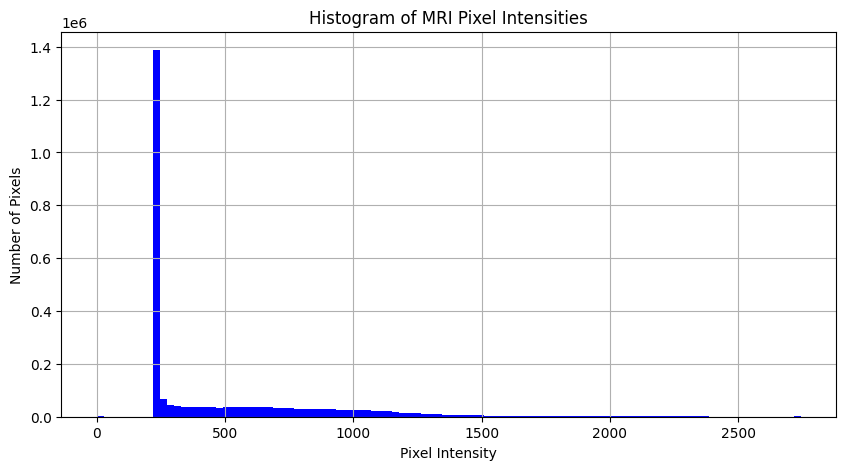

In [65]:
plt.figure(figsize=(10,5))

plt.hist(image.flatten(), bins=100, color='blue')

plt.title("Histogram of MRI Pixel Intensities")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.grid(True)

plt.show()

In [66]:
# Normalize image to the range [0, 1]

normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))

print("=" * 50)
print("NORMALIZATION COMPLETED")
print("=" * 50)

print(f"Minimum Value : {normalized_image.min():.4f}")
print(f"Maximum Value : {normalized_image.max():.4f}")
print(f"Mean Value    : {normalized_image.mean():.4f}")

NORMALIZATION COMPLETED
Minimum Value : 0.0000
Maximum Value : 1.0000
Mean Value    : 0.1792


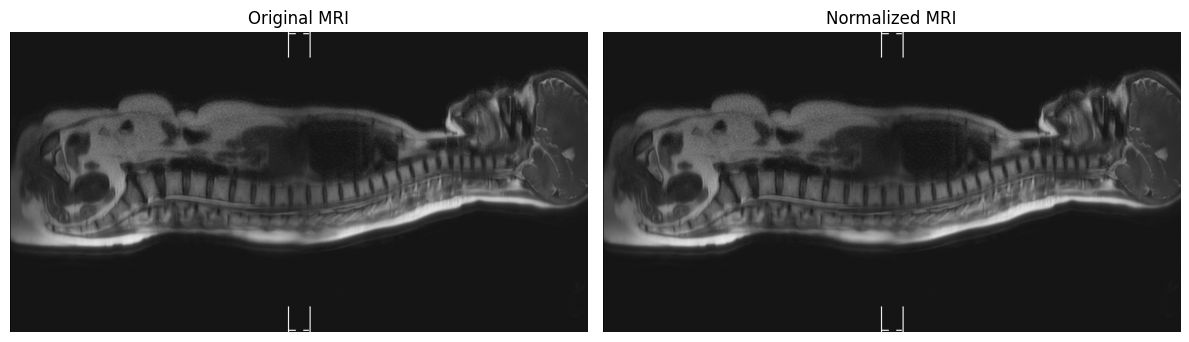

In [67]:
# Compare Original and Normalized MRI (Middle Slice)

middle_slice = image.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image[:, :, middle_slice], cmap='gray')
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(normalized_image[:, :, middle_slice], cmap='gray')
plt.title("Normalized MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [68]:
from scipy.ndimage import gaussian_filter

# Apply Gaussian filtering
gaussian_image = gaussian_filter(normalized_image, sigma=1)

print("=" * 50)
print("GAUSSIAN FILTER APPLIED")
print("=" * 50)
print("Image Shape:", gaussian_image.shape)

GAUSSIAN FILTER APPLIED
Image Shape: (528, 1017, 5)


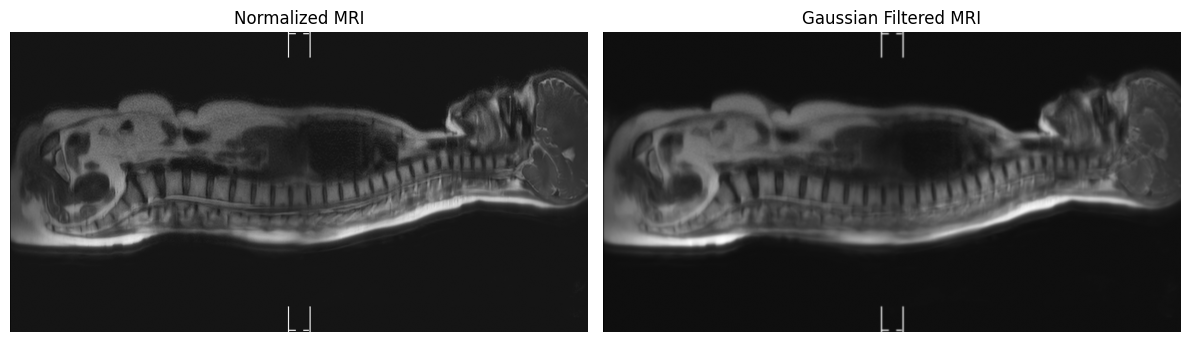

In [69]:
middle_slice = gaussian_image.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(normalized_image[:, :, middle_slice], cmap='gray')
plt.title("Normalized MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gaussian_image[:, :, middle_slice], cmap='gray')
plt.title("Gaussian Filtered MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [70]:
from scipy.ndimage import median_filter

# Apply Median Filter
median_image = median_filter(gaussian_image, size=3)

print("="*50)
print("MEDIAN FILTER APPLIED")
print("="*50)
print("Shape:", median_image.shape)

MEDIAN FILTER APPLIED
Shape: (528, 1017, 5)


In [71]:
import cv2

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_image = np.zeros_like(median_image)

for i in range(median_image.shape[2]):

    slice_img = (median_image[:,:,i]*255).astype(np.uint8)

    clahe_image[:,:,i] = clahe.apply(slice_img)/255.0

print("="*50)
print("CLAHE APPLIED")
print("="*50)

CLAHE APPLIED


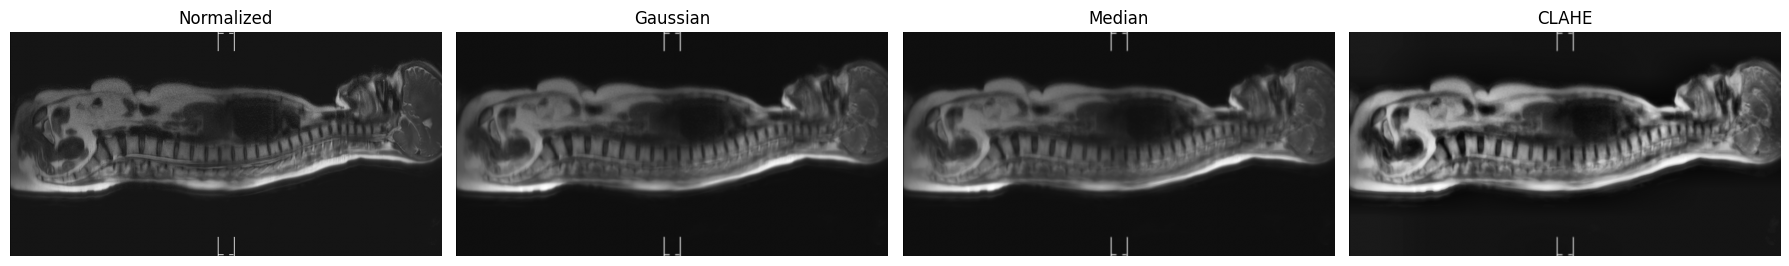

In [72]:
middle = image.shape[2]//2

plt.figure(figsize=(18,8))

plt.subplot(1,4,1)
plt.imshow(normalized_image[:,:,middle], cmap='gray')
plt.title("Normalized")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gaussian_image[:,:,middle], cmap='gray')
plt.title("Gaussian")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(median_image[:,:,middle], cmap='gray')
plt.title("Median")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(clahe_image[:,:,middle], cmap='gray')
plt.title("CLAHE")
plt.axis("off")

plt.tight_layout()

plt.show()

In [73]:

print("="*60)
print("IMAGE ENHANCEMENT SUMMARY")
print("="*60)

print("Original")
print("Min :", image.min())
print("Max :", image.max())
print()

print("Normalized")
print("Min :", normalized_image.min())
print("Max :", normalized_image.max())
print()

print("Gaussian")
print("Mean :", gaussian_image.mean())
print()

print("Median")
print("Mean :", median_image.mean())
print()

print("CLAHE")
print("Mean :", clahe_image.mean())

IMAGE ENHANCEMENT SUMMARY
Original
Min : 0.0
Max : 2744.781732559204

Normalized
Min : 0.0
Max : 1.0

Gaussian
Mean : 0.17919089475134822

Median
Mean : 0.17895172212398366

CLAHE
Mean : 0.23281009382388887


In [74]:
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

import math

In [75]:
# Use the middle slice for evaluation

middle = image.shape[2] // 2

original = normalized_image[:, :, middle]
enhanced = clahe_image[:, :, middle]

# MSE
mse = mean_squared_error(original, enhanced)

# RMSE
rmse = math.sqrt(mse)

# PSNR
psnr = peak_signal_noise_ratio(original, enhanced, data_range=1.0)

# SSIM
ssim = structural_similarity(original, enhanced, data_range=1.0)

print("="*60)
print("IMAGE QUALITY METRICS")
print("="*60)

print(f"MSE   : {mse:.6f}")
print(f"RMSE  : {rmse:.6f}")
print(f"PSNR  : {psnr:.4f} dB")
print(f"SSIM  : {ssim:.4f}")

IMAGE QUALITY METRICS
MSE   : 0.010651
RMSE  : 0.103204
PSNR  : 19.7260 dB
SSIM  : 0.8504


In [76]:
metrics = {
    "MSE": mse,
    "RMSE": rmse,
    "PSNR": psnr,
    "SSIM": ssim
}

print("\n")
print("="*60)
print("QUALITY METRIC SUMMARY")
print("="*60)

for name, value in metrics.items():
    print(f"{name:<10}: {value:.6f}")



QUALITY METRIC SUMMARY
MSE       : 0.010651
RMSE      : 0.103204
PSNR      : 19.726040
SSIM      : 0.850420


In [77]:
from skimage.measure import shannon_entropy

entropy_original = shannon_entropy(original)
entropy_enhanced = shannon_entropy(enhanced)

print("="*60)
print("ENTROPY")
print("="*60)
print(f"Original Image Entropy : {entropy_original:.4f}")
print(f"Enhanced Image Entropy : {entropy_enhanced:.4f}")

ENTROPY
Original Image Entropy : 6.4392
Enhanced Image Entropy : 6.1325


In [78]:
signal = np.mean(enhanced)
noise = np.std(enhanced - original)

snr = 20 * np.log10(signal / noise)

print("="*60)
print("SIGNAL TO NOISE RATIO")
print("="*60)
print(f"SNR : {snr:.4f} dB")

SIGNAL TO NOISE RATIO
SNR : 8.4093 dB


In [79]:
foreground = enhanced[enhanced > np.mean(enhanced)]
background = enhanced[enhanced <= np.mean(enhanced)]

cnr = abs(np.mean(foreground) - np.mean(background)) / np.std(background)

print("="*60)
print("CONTRAST TO NOISE RATIO")
print("="*60)
print(f"CNR : {cnr:.4f}")

CONTRAST TO NOISE RATIO
CNR : 11.0250


In [80]:
def uqi(img1, img2):
    x = img1.flatten()
    y = img2.flatten()

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    var_x = np.var(x)
    var_y = np.var(y)

    cov = np.mean((x - mean_x) * (y - mean_y))

    numerator = 4 * cov * mean_x * mean_y
    denominator = (var_x + var_y) * (mean_x**2 + mean_y**2)

    return numerator / denominator

uqi_score = uqi(original, enhanced)

print("="*60)
print("UNIVERSAL QUALITY INDEX")
print("="*60)
print(f"UQI : {uqi_score:.4f}")

UNIVERSAL QUALITY INDEX
UQI : 0.8435


In [81]:
print("="*70)
print("ADVANCED IMAGE QUALITY METRICS")
print("="*70)

print(f"Entropy (Original) : {entropy_original:.4f}")
print(f"Entropy (Enhanced) : {entropy_enhanced:.4f}")
print(f"SNR               : {snr:.4f} dB")
print(f"CNR               : {cnr:.4f}")
print(f"UQI               : {uqi_score:.4f}")

ADVANCED IMAGE QUALITY METRICS
Entropy (Original) : 6.4392
Entropy (Enhanced) : 6.1325
SNR               : 8.4093 dB
CNR               : 11.0250
UQI               : 0.8435


In [82]:

import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if files:
        print("Files:", files[:3])   # show first 3 files only
    print("-" * 70)

/kaggle/input
----------------------------------------------------------------------
/kaggle/input/datasets
----------------------------------------------------------------------
/kaggle/input/datasets/nnm24is112kruthin
----------------------------------------------------------------------
/kaggle/input/datasets/nnm24is112kruthin/spinal
----------------------------------------------------------------------
/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS
----------------------------------------------------------------------
/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS/Pathological Spine MRI Datasets
----------------------------------------------------------------------
/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS/Pathological Spine MRI Datasets/SP22
Files: ['S82231_MobiView_SURVEY_SAG_20260228094046_202.nii', 'S82231_eT1W_TSE_CLEAR_20260228094046_702_i00005.nii', 'S82231_eT2W_TSE_DRIVE_HR_20260228094046_802_i00013.nii']
----------------

In [ ]:
# Dataset Exploration

In this section, we analyse the Spine MRI dataset by counting the number of Normal and Pathological patient folders. This helps us understand the dataset distribution before training the AI model.

In [8]:
import os

dataset_path = "/kaggle/input/datasets/nnm24is112kruthin/spinal/Spine DATASETS"

normal_path = os.path.join(dataset_path, "Normal Spine MRI Datasets")
pathological_path = os.path.join(dataset_path, "Pathological Spine MRI Datasets")

normal_patients = sorted([
    folder for folder in os.listdir(normal_path)
    if os.path.isdir(os.path.join(normal_path, folder))
])

pathological_patients = sorted([
    folder for folder in os.listdir(pathological_path)
    if os.path.isdir(os.path.join(pathological_path, folder))
])

print("="*60)
print("SPINE MRI DATASET SUMMARY")
print("="*60)

print("Normal Patients      :", len(normal_patients))
print("Pathological Patients:", len(pathological_patients))
print("Total Patients       :", len(normal_patients)+len(pathological_patients))

SPINE MRI DATASET SUMMARY
Normal Patients      : 10
Pathological Patients: 10
Total Patients       : 20


In [ ]:
# Train, Validation and Test Split

The dataset is divided at the **patient level** to prevent data leakage. All MRI sequences belonging to the same patient remain in the same subset.

Split Ratio:
- Training : 70%
- Validation : 15%
- Testing : 15%

This split provides sufficient data for model learning while reserving independent data for validation and final testing.

In [9]:
from sklearn.model_selection import train_test_split

# Create patient list with labels
patients = []

for patient in normal_patients:
    patients.append((os.path.join(normal_path, patient), 0))

for patient in pathological_patients:
    patients.append((os.path.join(pathological_path, patient), 1))

# First split: Train (70%) and Remaining (30%)
train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42,
    stratify=[label for _, label in patients]
)

# Second split: Validation (15%) and Test (15%)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42,
    stratify=[label for _, label in temp_patients]
)

print("=" * 60)
print("DATASET SPLIT SUMMARY")
print("=" * 60)

print(f"Training Patients   : {len(train_patients)}")
print(f"Validation Patients : {len(val_patients)}")
print(f"Testing Patients    : {len(test_patients)}")
print(f"Total Patients      : {len(patients)}")

DATASET SPLIT SUMMARY
Training Patients   : 14
Validation Patients : 3
Testing Patients    : 3
Total Patients      : 20


In [ ]:
# MRI File Collection

In this step, all MRI (.nii) files are collected from the patient folders. Each MRI file is assigned the corresponding patient label for model training.

In [10]:
import os

train_files = []
val_files = []
test_files = []

def collect_nii_files(patient_list, destination):
    for patient_path, label in patient_list:
        for file in sorted(os.listdir(patient_path)):
            if file.endswith(".nii"):
                destination.append(
                    (os.path.join(patient_path, file), label)
                )

collect_nii_files(train_patients, train_files)
collect_nii_files(val_patients, val_files)
collect_nii_files(test_patients, test_files)

print("="*60)
print("MRI FILE SUMMARY")
print("="*60)

print(f"Training MRI Files   : {len(train_files)}")
print(f"Validation MRI Files : {len(val_files)}")
print(f"Testing MRI Files    : {len(test_files)}")
print(f"Total MRI Files      : {len(train_files)+len(val_files)+len(test_files)}")

MRI FILE SUMMARY
Training MRI Files   : 229
Validation MRI Files : 69
Testing MRI Files    : 46
Total MRI Files      : 344


In [ ]:
# Sample MRI Visualization

Random MRI slices are displayed from the training dataset to verify that the MRI files have been loaded correctly before model training.

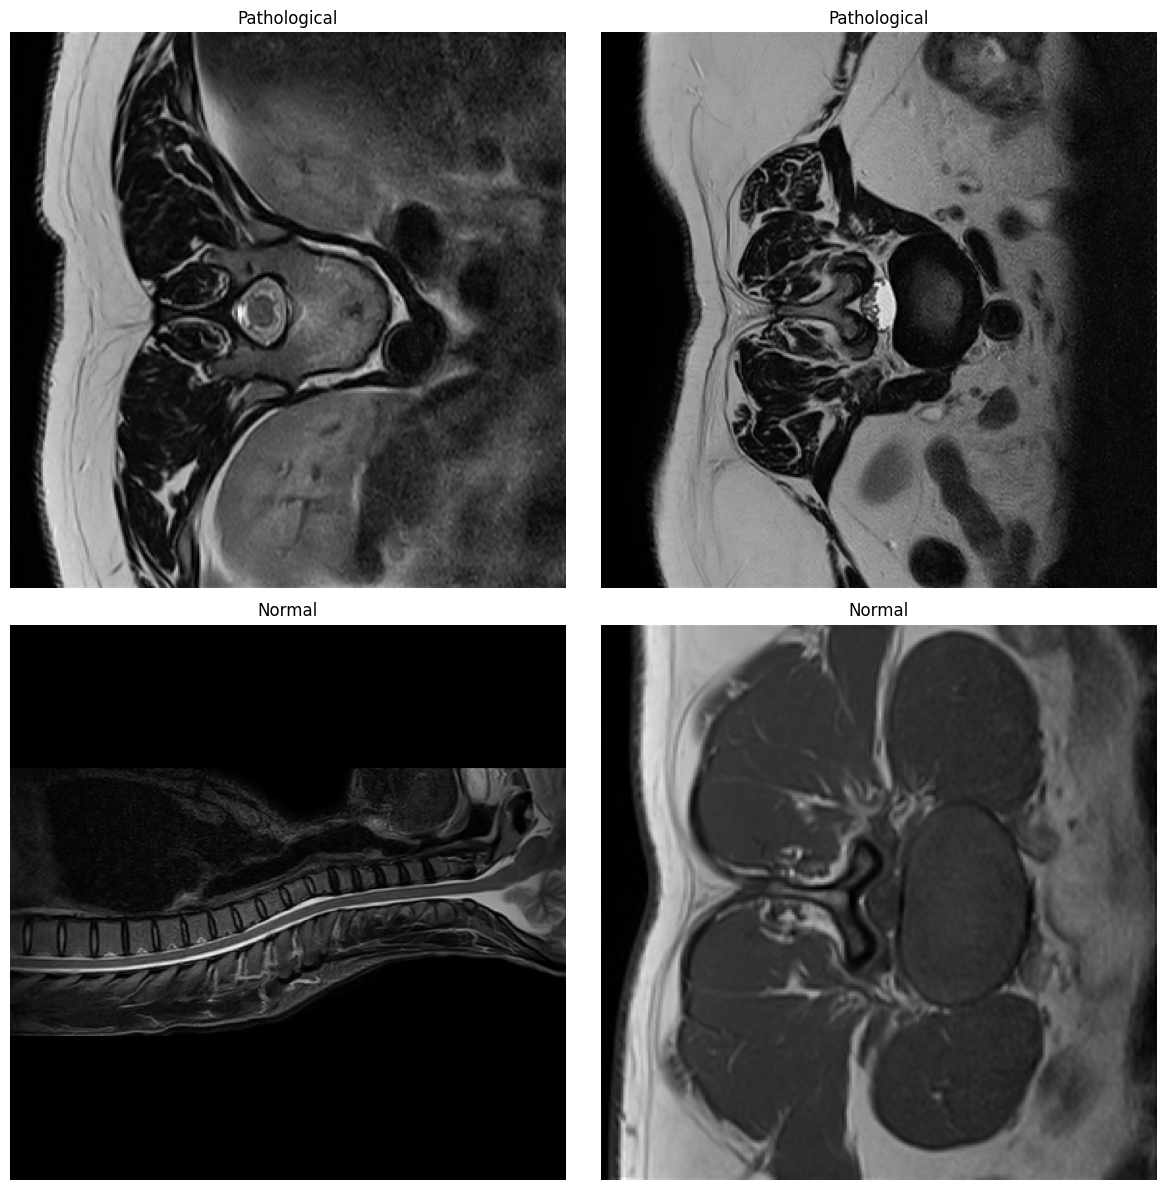

In [12]:
import random
import nibabel as nib
import matplotlib.pyplot as plt

# Randomly select 4 MRI files
sample_files = random.sample(train_files, 4)

plt.figure(figsize=(12, 12))

for i, (file_path, label) in enumerate(sample_files):

    # Load MRI volume
    volume = nib.load(file_path).get_fdata()

    # Select middle slice
    middle_slice = volume.shape[2] // 2
    slice_image = volume[:, :, middle_slice]

    # Display image
    plt.subplot(2, 2, i + 1)
    plt.imshow(slice_image, cmap="gray")

    # Display class label
    if label == 0:
        plt.title("Normal")
    else:
        plt.title("Pathological")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# MRI Slice Preparation

Each MRI volume is converted into a representative middle slice. The slice is resized to 224 × 224 pixels and normalized to the range [0,1]. This creates a consistent dataset for CNN-based classification.

In [14]:
import cv2
import numpy as np
import nibabel as nib

IMG_SIZE = 224

def load_middle_slice(file_path):
    """
    Load MRI volume and automatically select the slice
    with the highest standard deviation (most information).
    """

    # Load MRI volume
    volume = nib.load(file_path).get_fdata()

    # Calculate standard deviation for every slice
    slice_scores = []

    for i in range(volume.shape[2]):
        score = np.std(volume[:, :, i])
        slice_scores.append(score)

    # Select the slice with maximum information
    best_slice = np.argmax(slice_scores)

    # Extract the selected slice
    image = volume[:, :, best_slice]

    # Convert to float32
    image = image.astype(np.float32)

    # Normalize to 0–1
    image = (image - image.min()) / (image.max() - image.min() + 1e-8)

    # Resize to EfficientNet input size
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    return image

In [ ]:
# Dataset Preparation

The MRI slices are converted into NumPy arrays along with their corresponding labels. These arrays are used as input for the deep learning model.

In [15]:
X_train = []
y_train = []

X_val = []
y_val = []

X_test = []
y_test = []


def prepare_dataset(file_list, images, labels):

    for file_path, label in file_list:

        try:

            img = load_middle_slice(file_path)

            images.append(img)

            labels.append(label)

        except Exception:

            continue


prepare_dataset(train_files, X_train, y_train)
prepare_dataset(val_files, X_val, y_val)
prepare_dataset(test_files, X_test, y_test)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("="*60)
print("DATASET READY")
print("="*60)

print("Training :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing :", X_test.shape)

DATASET READY
Training : (229, 224, 224)
Validation : (69, 224, 224)
Testing : (46, 224, 224)


In [ ]:
# Data Formatting

The MRI slices are reshaped by adding a single channel dimension, converting each image from 224 × 224 to 224 × 224 × 1. This format is required for CNN-based deep learning models.

In [16]:
# Add channel dimension

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("=" * 60)
print("INPUT SHAPES")
print("=" * 60)

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

INPUT SHAPES
Training   : (229, 224, 224, 1)
Validation : (69, 224, 224, 1)
Testing    : (46, 224, 224, 1)


In [ ]:
# Preparing Data for Transfer Learning

The grayscale MRI images are converted into three-channel images because the EfficientNetB0 architecture expects RGB input. Although the three channels contain identical grayscale information, this allows us to leverage pretrained ImageNet weights.

In [17]:
import numpy as np

# Convert grayscale (1 channel) to RGB (3 channels)

X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb = np.repeat(X_val, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print("="*60)
print("RGB DATASET SHAPES")
print("="*60)

print("Training   :", X_train_rgb.shape)
print("Validation :", X_val_rgb.shape)
print("Testing    :", X_test_rgb.shape)

RGB DATASET SHAPES
Training   : (229, 224, 224, 3)
Validation : (69, 224, 224, 3)
Testing    : (46, 224, 224, 3)


In [ ]:
# EfficientNetB0 Model

A pretrained EfficientNetB0 model is used as the backbone for MRI classification. Transfer learning enables the model to learn meaningful image features efficiently while reducing training time. A custom classification head is added for binary classification (Normal vs Pathological).

In [18]:
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model

# Load pretrained EfficientNetB0
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
base_model.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

print("="*60)
print("MODEL CREATED SUCCESSFULLY")
print("="*60)

I0000 00:00:1784938590.342269      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784938590.345120      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MODEL CREATED SUCCESSFULLY


In [ ]:
# Model Compilation

The EfficientNetB0 model is compiled using the Adam optimizer with binary cross-entropy loss. Model accuracy is used as the primary evaluation metric for binary classification.

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("=" * 60)
print("MODEL COMPILED SUCCESSFULLY")
print("=" * 60)

MODEL COMPILED SUCCESSFULLY


In [ ]:
# Model Training

The model is trained using transfer learning. Early stopping is applied to prevent overfitting, and the best-performing model based on validation accuracy is saved automatically.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_efficientnet_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    X_train_rgb,
    y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20


2026-07-25 00:17:35.994817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:36.132933: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:36.454722: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:36.595075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:37.380373: E external/local_xla/xla/stream_

13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4656 - loss: 0.7121

2026-07-25 00:17:51.673985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:51.808323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:52.129309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:52.269091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:17:53.048658: E external/local_xla/xla/stream_

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4739 - loss: 0.7102  
Epoch 1: val_accuracy improved from None to 0.50725, saving model to best_efficientnet_model.keras

Epoch 1: finished saving model to best_efficientnet_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.5284 - loss: 0.6981 - val_accuracy: 0.5072 - val_loss: 0.7197
Epoch 2/20
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5348 - loss: 0.7010
Epoch 2: val_accuracy did not improve from 0.50725
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5721 - loss: 0.6732 - val_accuracy: 0.5072 - val_loss: 0.7200
Epoch 3/20
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5496 - loss: 0.7200
Epoch 3: val_accuracy did not improve from 0.50725
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5808 - loss: 0.6947 - val_accuracy: 0.5072 - val_loss: 0.7083
Epoch 4/20
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5982 - loss: 0.6753
Epoch 4: val_accuracy did not improve from 0.50725
15/15 ━

In [ ]:
# Training Performance

The training and validation accuracy and loss curves are plotted to analyse the learning behaviour of the model and identify any signs of overfitting or underfitting.

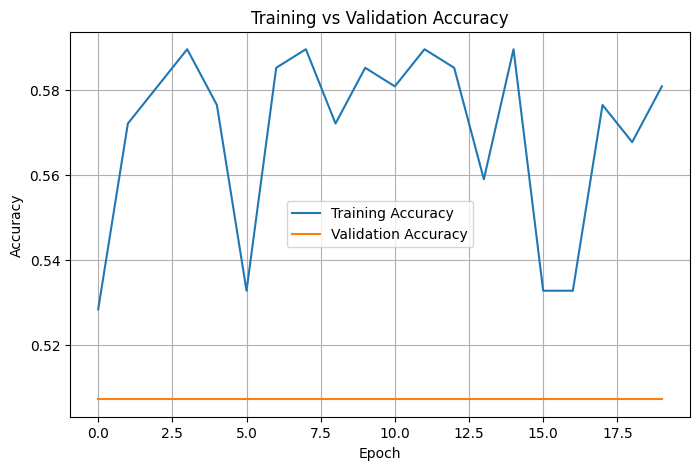

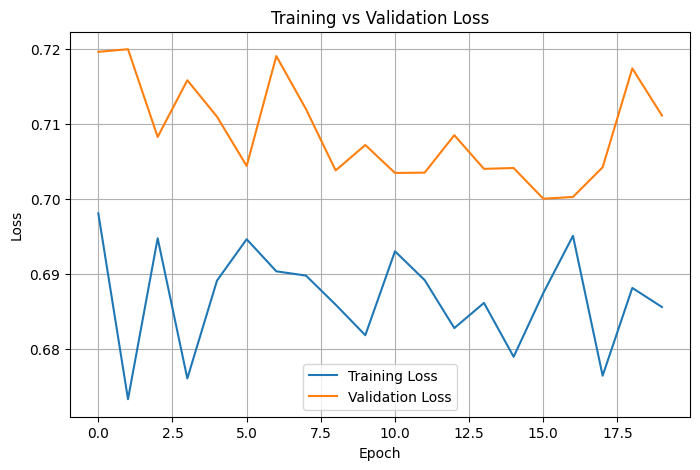

In [21]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Model Evaluation

The trained EfficientNetB0 model is evaluated on the independent test dataset. The evaluation reports the test loss and classification accuracy.

In [22]:
test_loss, test_accuracy = model.evaluate(
    X_test_rgb,
    y_test,
    verbose=1
)

print("=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

2026-07-25 00:20:33.767780: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:33.911035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:34.254811: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:34.395524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:35.184251: E external/local_xla/xla/stream_

1/2 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.0000e+00 - loss: 0.8348

2026-07-25 00:20:43.517861: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:43.656323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:43.971124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:44.112339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-25 00:20:44.893813: E external/local_xla/xla/stream_

2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 10s/step - accuracy: 0.2391 - loss: 0.7712  
TEST RESULTS
Test Loss     : 0.7712
Test Accuracy : 23.91%


In [ ]:
# Model Predictions

The trained model predicts whether each MRI image belongs to the Normal or Pathological class.

In [23]:
import numpy as np

predictions = model.predict(X_test_rgb)

predicted_labels = (predictions > 0.5).astype(int).flatten()

print("=" * 60)
print("FIRST 10 PREDICTIONS")
print("=" * 60)

for i in range(min(10, len(predicted_labels))):
    print(f"Actual: {y_test[i]}   Predicted: {predicted_labels[i]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step
FIRST 10 PREDICTIONS
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1
Actual: 0   Predicted: 1


In [ ]:

# Confusion Matrix

The confusion matrix summarizes the model's classification performance by comparing the predicted labels with the true labels.

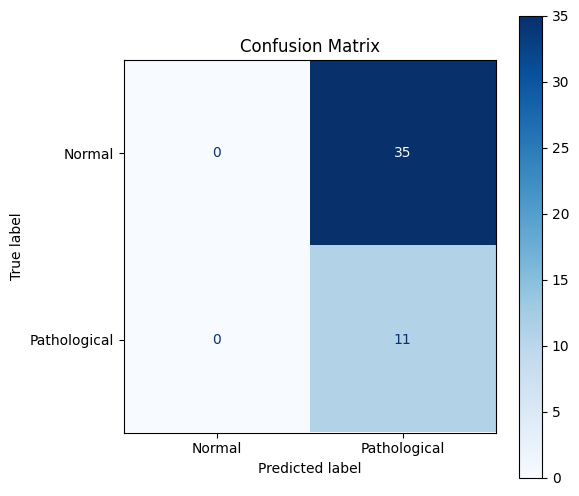

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Pathological"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report

Precision, Recall, F1-score and Accuracy are used to evaluate the performance of the proposed model.

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted_labels,
    target_names=["Normal", "Pathological"]
))

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        35
Pathological       0.24      1.00      0.39        11

    accuracy                           0.24        46
   macro avg       0.12      0.50      0.19        46
weighted avg       0.06      0.24      0.09        46



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ROC Curve

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate for different classification thresholds.

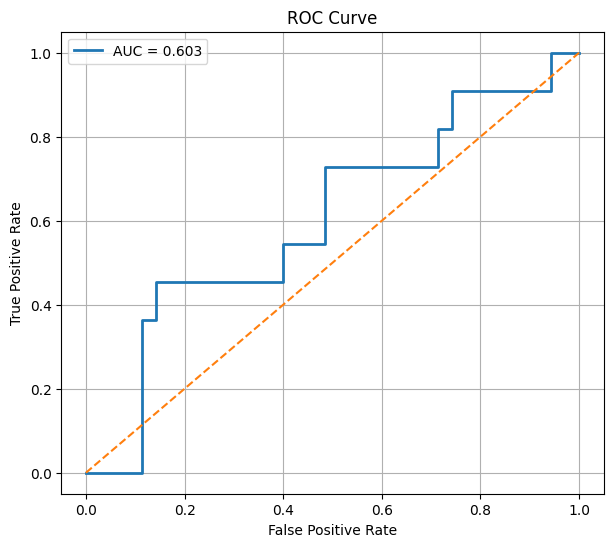

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, predictions)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Fine-Tuning the Model

To improve the model's performance, the last layers of EfficientNetB0 are unfrozen and trained with a lower learning rate. Fine-tuning allows the pretrained model to adapt better to spine MRI images.

In [29]:
# Unfreeze the last 20 layers
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully!")

Fine-tuning model compiled successfully!


In [ ]:
# Fine-Tuning Training

The unfrozen EfficientNetB0 layers are trained with a lower learning rate to improve feature extraction from spine MRI images while reducing the risk of overfitting.

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

fine_tune_history = model.fit(
    X_train_rgb,
    y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=8,
    batch_size=16,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4629 - loss: 0.7020 - val_accuracy: 0.5072 - val_loss: 0.7027
Epoch 2/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4847 - loss: 0.7061 - val_accuracy: 0.5072 - val_loss: 0.7063
Epoch 3/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5284 - loss: 0.6982 - val_accuracy: 0.5072 - val_loss: 0.7098
Epoch 4/8
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4541 - loss: 0.7119 - val_accuracy: 0.5072 - val_loss: 0.7125


In [31]:
test_loss, test_accuracy = model.evaluate(
    X_test_rgb,
    y_test,
    verbose=1
)

print("=" * 60)
print("FINE-TUNED MODEL RESULTS")
print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.2391 - loss: 0.7849   
FINE-TUNED MODEL RESULTS
Test Loss     : 0.7849
Test Accuracy : 23.91%


In [32]:
print("Training labels:")
print(np.unique(y_train, return_counts=True))

print("\nValidation labels:")
print(np.unique(y_val, return_counts=True))

print("\nTesting labels:")
print(np.unique(y_test, return_counts=True))

Training labels:
(array([0, 1]), array([ 96, 133]))

Validation labels:
(array([0, 1]), array([34, 35]))

Testing labels:
(array([0, 1]), array([35, 11]))
